# Ноутбук с SHAP анализом

## 1. Импорт бибилиотек и конфигурация проекта

In [14]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.linear_model import Ridge
from category_encoders.cat_boost import CatBoostEncoder
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import GridSearchCV, KFold, RandomizedSearchCV
import copy
from sklearn.model_selection import cross_val_score
import optuna
from sklearn.model_selection import cross_validate
import xgboost as xgb
import pyarrow
import phik
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
import catboost
from optuna.visualization import (
    plot_optimization_history,
    plot_param_importances,
    plot_parallel_coordinate
)
from catboost import CatBoostRegressor
import mlflow.sklearn
from phik.report import plot_correlation_matrix
import plotly
import mlflow
import time
from scipy.stats import randint, uniform, loguniform
import os
from datetime import datetime
import category_encoders as ce
import joblib
from sklearn.inspection import PartialDependenceDisplay
import shap
from catboost import Pool

In [15]:
# Создадим словарь конфигураций.

CONFIG = {
    # Константы
    "DEV_MODE": False,
    "DEV_SAMPLE_SIZE": 100000,
    "RANDOM_STATE": 42,
    # Целевая переменная 
    "TARGET": "Цена",
    "YEAR": datetime.now().year
}

In [16]:
train = pd.read_parquet("../data/optimized/train_optimized.parquet")
test = pd.read_parquet("../data/optimized/test_optimized.parquet")

In [17]:
X_train = train.drop(columns=[CONFIG["TARGET"]])
y_train = train[CONFIG["TARGET"]]
X_test = test.drop(columns=[CONFIG["TARGET"]])
y_test = test[CONFIG["TARGET"]]

dir = 'C:/project/car-price-analyzer/src/mlflow_runs'
os.makedirs(dir, exist_ok=True)
mlflow.set_tracking_uri(f'sqlite:///{dir}/mlflow.db')
mlflow.set_experiment('shap-interpretation')

<Experiment: artifact_location='file:c:/project/car-price-analyzer/researches/mlruns/7', creation_time=1785940437670, effective_trace_archival_retention=None, experiment_id='7', last_update_time=1785940437670, lifecycle_stage='active', name='shap-interpretation', tags={}, trace_location=None, workspace='default'>

In [18]:
cb_model = joblib.load('../models/best_catboost_model.pkl')
model = cb_model.regressor_

## 2. Построение графиков

In [19]:
cat_cols = X_train.select_dtypes(['object', 'category']).columns.to_list()
text_features = model.get_text_feature_indices()
pool = Pool(X_test, cat_features=cat_cols, text_features=text_features)
shap_matrix = model.get_feature_importance(pool, type='ShapValues')
shap_values_matrix = shap_matrix[:, :-1]
base_values = shap_matrix[:, -1]

In [20]:
explanation = shap.Explanation(
    values=shap_values_matrix,
    base_values=base_values,
    data=X_test,
    feature_names=X_test.columns
)

In [25]:
run_name='shap_plots'
with mlflow.start_run(run_name=run_name):
    shap.plots.beeswarm(explanation, max_display=27, show=False)
    mlflow.log_figure(plt.gcf(), artifact_file="shap_beeswarm.png")
    plt.close()
    shap.plots.waterfall(explanation[100], max_display=27, show=False)
    mlflow.log_figure(plt.gcf(), artifact_file="waterfall_lada_2106.png")
    plt.close()
    shap.plots.waterfall(explanation[1000], show=False)
    mlflow.log_figure(plt.gcf(), artifact_file="waterfall_haval_f7.png")
    plt.close()


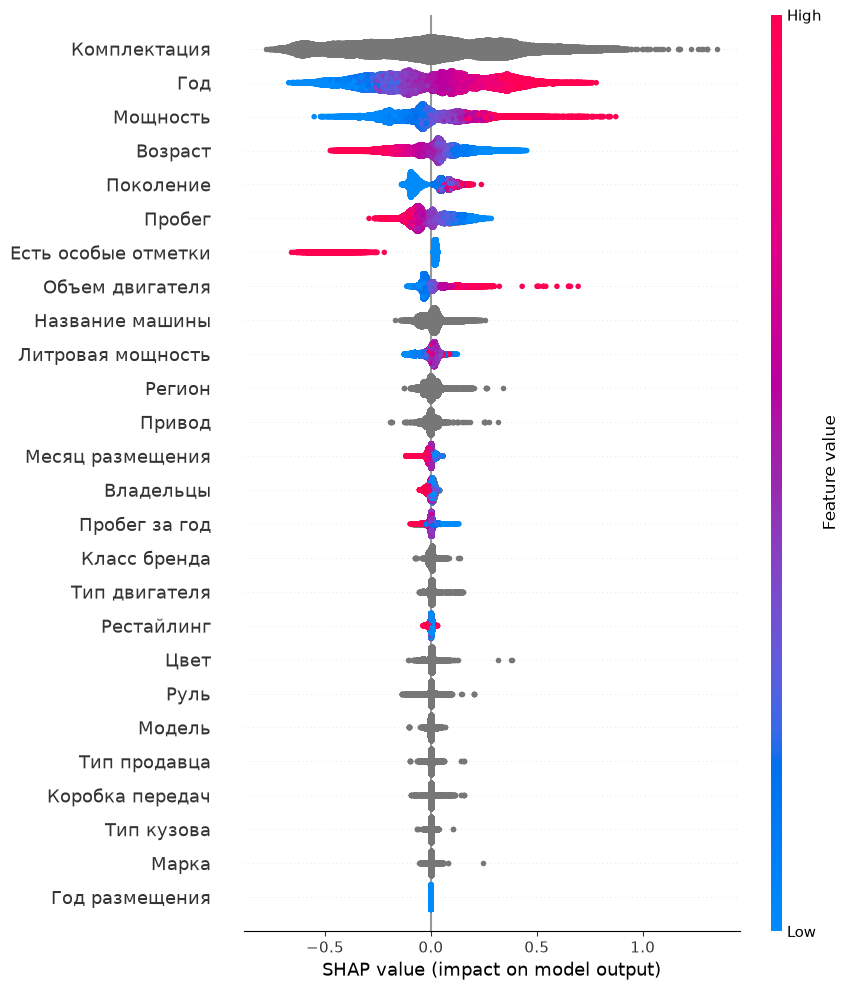

In [ ]:
shap.plots.beeswarm(explanation, max_display=27, show=False)

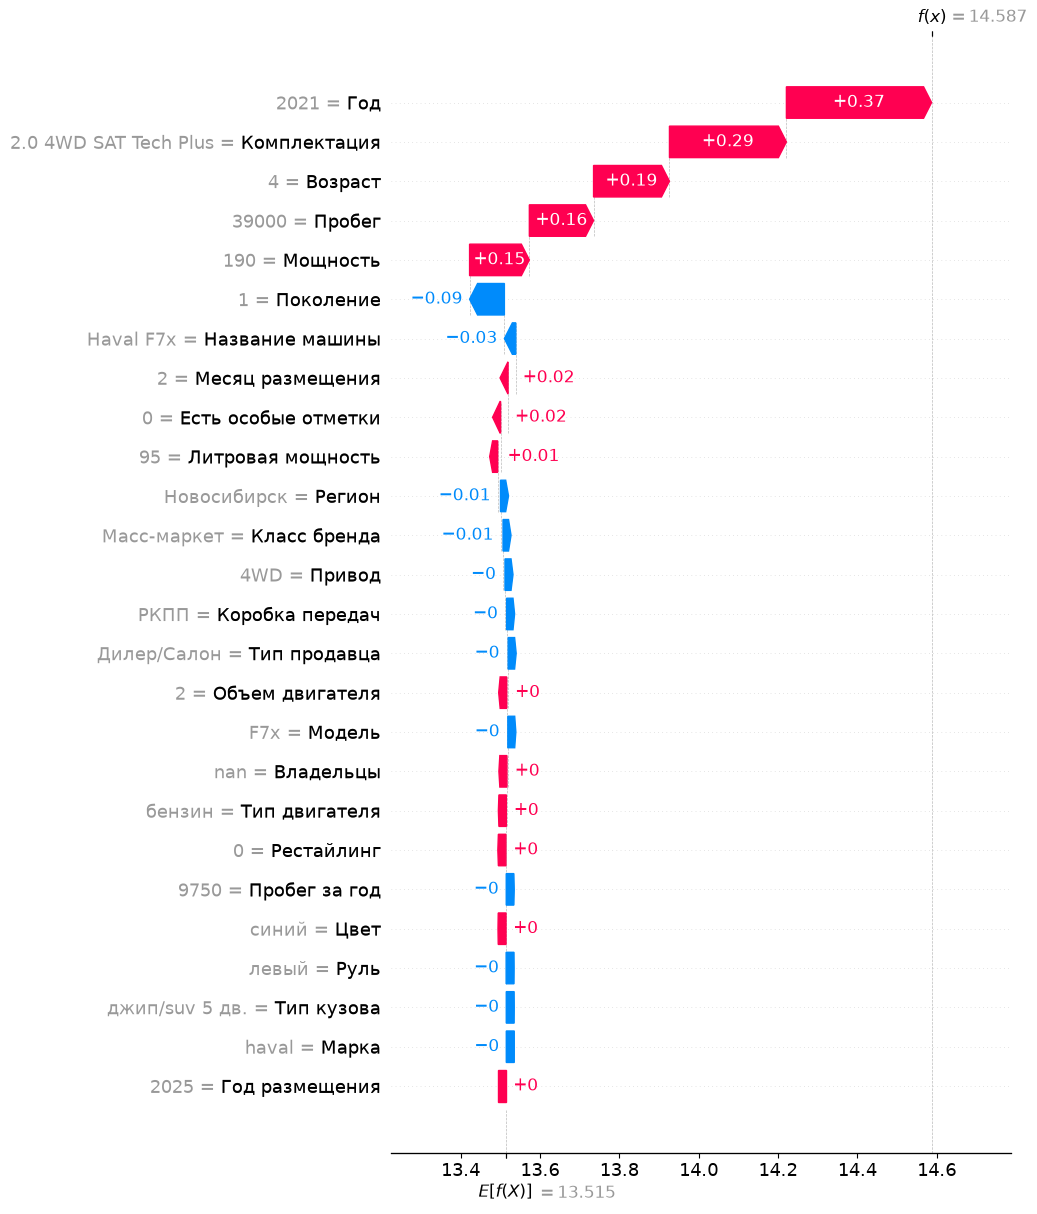

In [31]:
shap.plots.waterfall(explanation[50000], max_display=27)